# Heading timing — plan-time vs arrival-time (does it reduce spins without losing coverage?)

`plan_waypoints` currently fills `wp.headings` at **plan time**, from the `covered_mask` as it is
*during planning*. By the time the robot reaches a waypoint, earlier waypoints in the same plan
have already observed cells, so that mask is stale — the stored headings may aim the camera at
cells already covered en route.

Proposed (same logic, fresher input): compute headings **at arrival**, from the current
`covered_mask`, via `compute_visibility` (uncovered cells now visible) → `compute_headings_for_waypoint`.

This notebook A/B-simulates the full explore loop headlessly (reusing the `visual_demo` loop
structure, minus ROS/plots) on the real maps and measures:
- **total spins executed** (each heading = one physical Spin),
- **redundant spins** (a heading that added **zero** new covered cells),
- **final coverage %** and **waypoints visited**.

**Decision rule (agreed up front):** adopt arrival-time only if it gives **fewer-or-equal total
spins AND does not reduce final coverage**. If it's worse or a wash, keep plan-time.

In [1]:
import sys, math
from collections import deque
from pathlib import Path
import numpy as np, yaml
from PIL import Image

ROOT = Path.cwd()
while not (ROOT / ".git").exists() and not (ROOT / "docker-compose.yml").is_file():
    ROOT = ROOT.parent
ASSETS = ROOT / "assets"
sys.path.insert(0, str(ROOT / "ros2_ws/src/navigation/exploration"))

from exploration.explore_costmap_map import (
    build_map_data, compute_visibility, compute_headings_for_waypoint, update_covered_mask,
)
from exploration.execution_strategy import ExplorationSession
from exploration.rotation_strategy import get_headings, RotationState
print("repo root:", ROOT)

repo root: /home/idlab332/workspace/ros_ws/src/TRAVIS


In [2]:
def find_path(navigable_mask, start, goal):
    """BFS shortest 8-connected path (col,row) list; [start] if no path. Copy of demo_robot.find_path."""
    if start == goal:
        return [start]
    H, W = navigable_mask.shape
    q = deque([start]); came = {start: None}
    nb = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    while q:
        col, row = q.popleft()
        if (col, row) == goal:
            break
        for dc, dr in nb:
            nc, nr = col+dc, row+dr
            if 0 <= nc < W and 0 <= nr < H and navigable_mask[nr, nc] and (nc, nr) not in came:
                came[(nc, nr)] = (col, row); q.append((nc, nr))
    if goal not in came:
        return [start]
    path = [goal]
    while path[-1] != start:
        path.append(came[path[-1]])
    return path[::-1]


def load_map(name):
    d = ASSETS / name
    yml = yaml.safe_load(open(d / "map.yaml"))
    arr = np.array(Image.open(d / "map.pgm"), dtype=np.uint8)
    res = float(yml["resolution"])
    return build_map_data(1.0 - arr / 255.0, res, float(yml["origin"][0]),
                          float(yml["origin"][1]), inflation_radius_m=0.9)


def base_cfg():
    return {"max_detection_range": 6.0, "fov_horizontal": 87.0,
            "observation_rotation_increment": 30.0, "sampling_step_m": 3.0,
            "num_rays": 360, "frontier_weight": 1.0, "coverage_weight": 1.0,
            "travel_cost_weight": 1.0, "exploration_completion_threshold": 0.90,
            "planner_coverage_warning_threshold": 0.0}

## The simulated explore loop (headless), parametrised by heading source

Mirrors the `visual_demo` loop: plan → walk BFS path → rotate through headings, calling
`update_covered_mask` per heading with `RotationState(stop_after=3)` early-stop. The **only**
difference between arms is how the rotation headings are obtained:
- `mode='plan'`  → `get_headings(wp, inc, heading)` using `wp.headings` from `plan_waypoints`.
- `mode='arrival'` → recompute from the live `covered_mask`: `compute_visibility` at the wp →
  `compute_headings_for_waypoint(...)` → then the same clockwise sort `get_headings` applies.

In [3]:
def _arrival_headings(md, wp, cfg, max_range_px, current_heading):
    """Headings computed from the CURRENT covered_mask (fresh input, same logic as planner)."""
    cov_cells, _ = compute_visibility((wp.col, wp.row), md, max_range_px, cfg["num_rays"])
    headings = compute_headings_for_waypoint(
        wp.col, wp.row, cov_cells,
        fov_deg=cfg["fov_horizontal"], increment_deg=cfg["observation_rotation_increment"])
    # apply the same clockwise-from-current sort get_headings uses (fallback to 360° if empty)
    if not headings:
        headings = [float(h) for h in range(0, 360, int(cfg["observation_rotation_increment"]))]
    return sorted((float(h) for h in headings), key=lambda h: (h - current_heading) % 360.0)


def simulate(md, cfg, mode, start_cx, start_cy, max_iters=200):
    """Run the explore loop headless, mirroring ros2_exploration_node.

    CRITICAL: the node DRAINS a plan — after finishing waypoint k it goes straight to waypoint k+1
    of the SAME plan (_finish_waypoint), and only replans when the plan is exhausted. So waypoints
    2..N of a plan use plan-time headings computed against a covered_mask that is now STALE (wps
    1..k-1 have since covered cells). That staleness is exactly what the arrival-time arm avoids —
    and it only exists because we execute multiple waypoints per plan. (An earlier version of this
    sim replanned every waypoint, which structurally erased the staleness → false tie.)

    mode in {'plan','arrival'}.
    """
    from exploration.explore_costmap_map import pixel_to_world
    md.covered_mask[:] = False
    H = md.pgm_array.shape[0]
    res = md.resolution
    max_range_px = max(1, int(cfg["max_detection_range"] / res))
    inc = cfg["observation_rotation_increment"]; fov = cfg["fov_horizontal"]; nrays = cfg["num_rays"]

    session = ExplorationSession(md, cfg)
    robot_col, robot_row = session.nearest_start(start_cx, start_cy)
    robot_x, robot_y = pixel_to_world(robot_col, robot_row, res, md.origin_x, md.origin_y, H)
    heading = 0.0
    total_spins = 0; redundant_spins = 0; waypoints_visited = 0; final_ratio = 0.0

    for _ in range(max_iters):
        waypoints, ratio, no_frontiers, _ = session.plan_waypoints_raw(robot_x, robot_y)
        final_ratio = ratio
        if (no_frontiers and ratio >= cfg["exploration_completion_threshold"]) or not waypoints:
            break

        # DRAIN the plan: execute every waypoint in order before replanning (like the node).
        for wp in waypoints:
            path = find_path(md.navigable_mask, (robot_col, robot_row), (wp.col, wp.row))
            if session.on_unreachable(wp, path):
                continue  # node treats a rejected/unreachable goal as skip (no coverage, no mark)

            # travel (arrival-only marking: no coverage update in transit)
            robot_col, robot_row = wp.col, wp.row
            robot_x, robot_y = wp.x, wp.y

            # rotate — headings from plan-time set vs recomputed at arrival
            if mode == "plan":
                rot_headings = get_headings(wp, inc, heading)
            else:
                rot_headings = _arrival_headings(md, wp, cfg, max_range_px, heading)
            rot = RotationState(stop_after=3)
            for h in rot_headings:
                heading = float(h)
                before = int(np.sum(md.covered_mask & md.free_mask))
                ratio = update_covered_mask(md, wp.col, wp.row, heading, fov, max_range_px, nrays)
                after = int(np.sum(md.covered_mask & md.free_mask))
                total_spins += 1
                if after == before:
                    redundant_spins += 1
                if not rot.update(ratio):
                    break
            session.on_arrive(wp)
            waypoints_visited += 1
            final_ratio = ratio

    return {"total_spins": total_spins, "redundant_spins": redundant_spins,
            "waypoints_visited": waypoints_visited, "final_coverage": round(final_ratio, 4)}

## A/B run on the real maps

In [4]:
def _md_from_free(free, res=0.05, infl_px=1.0):
    return build_map_data((~free).astype(float), res, 0.0, 0.0, inflation_radius_m=infl_px * res)

def make_ring():
    f = np.zeros((160, 160), bool); f[20:140, 20:140] = True; f[55:105, 55:105] = False
    return _md_from_free(f)

def make_L():
    f = np.zeros((160, 160), bool); f[20:60, 20:140] = True; f[20:140, 20:60] = True
    return _md_from_free(f)

def make_multi():
    f = np.zeros((240, 240), bool)
    f[10:50, 10:50] = True; f[10:50, 190:230] = True; f[190:230, 100:140] = True
    return _md_from_free(f)

def make_open_room(n=300):
    # large open box — many waypoints, run won't truncate at 2 wps like the cluttered real maps
    f = np.zeros((n, n), bool); f[10:n-10, 10:n-10] = True
    return _md_from_free(f)

MAPS = {
    "lab_ghent":    load_map("lab_ghent"),
    "lab_05":       load_map("lab_05"),
    "ring":         make_ring(),
    "L":            make_L(),
    "multi-region": make_multi(),
    "open_room":    make_open_room(),
}
cfg = base_cfg()

print(f"{'map':<13}{'mode':<9}{'spins':>7}{'redundant':>11}{'wps':>6}{'coverage':>10}")
results = {}
for name, md in MAPS.items():
    H, W = md.pgm_array.shape
    cx, cy = W // 2, H // 2
    for mode in ("plan", "arrival"):
        m = simulate(md, cfg, mode, cx, cy)
        results[(name, mode)] = m
        print(f"{name:<13}{mode:<9}{m['total_spins']:>7}{m['redundant_spins']:>11}"
              f"{m['waypoints_visited']:>6}{m['final_coverage']*100:>9.1f}%")

print()
for name in MAPS:
    p, a = results[(name, "plan")], results[(name, "arrival")]
    d_spins = a["total_spins"] - p["total_spins"]
    d_cov = a["final_coverage"] - p["final_coverage"]
    verdict = ("arrival better" if d_spins < 0 and d_cov >= -1e-9 else
               "tie" if d_spins == 0 and abs(d_cov) < 1e-9 else
               "arrival worse" if d_spins > 0 or d_cov < -1e-9 else "mixed")
    print(f"{name:<13}: Δspins={d_spins:+d}  Δcoverage={d_cov*100:+.2f}%  wps(plan/arr)="
          f"{p['waypoints_visited']}/{a['waypoints_visited']}  → {verdict}")

map          mode       spins  redundant   wps  coverage
lab_ghent    plan          40          7     5     18.6%
lab_ghent    arrival       25          0     5     18.6%
lab_05       plan          55          0     8     84.5%
lab_05       arrival       52          0     8     84.5%
ring         plan          35         11     5     99.9%
ring         arrival       22          0     5     99.9%
L            plan          36         11     5    100.0%
L            arrival       20          0     5    100.0%
multi-region plan           8          0     1     33.3%
multi-region arrival        8          0     1     33.3%
open_room    plan          56          1     7     97.6%
open_room    arrival       53          1     7     97.6%

lab_ghent    : Δspins=-15  Δcoverage=+0.00%  wps(plan/arr)=5/5  → arrival better
lab_05       : Δspins=-3  Δcoverage=+0.00%  wps(plan/arr)=8/8  → arrival better
ring         : Δspins=-13  Δcoverage=+0.00%  wps(plan/arr)=5/5  → arrival better
L            : Δ

## Visualise the rotations + richer efficiency metrics

Spin *count* hides two things: **angular travel** (turning 3× by 10° is far cheaper than 3× by
120°) and **coverage-gain per spin** (efficiency). This instruments the drain-the-plan sim to
record, per spin: heading, signed angular step, and new cells covered — then:
1. plots the **FOV wedges** the robot actually sweeps at each waypoint (plan vs arrival), over the
   covered_mask, so you can *see* how blind spots get filled;
2. reports **total angular travel (deg)**, **coverage-gain per spin**, and **redundant spins**.

[ring]  headline cost = total angular travel (proxy for time + drift):
  plan     ANG_TRAVEL=  1530°  spins= 35  cov/deg=  7.8  near-redundant(<5%)=21  (zero-gain=11)


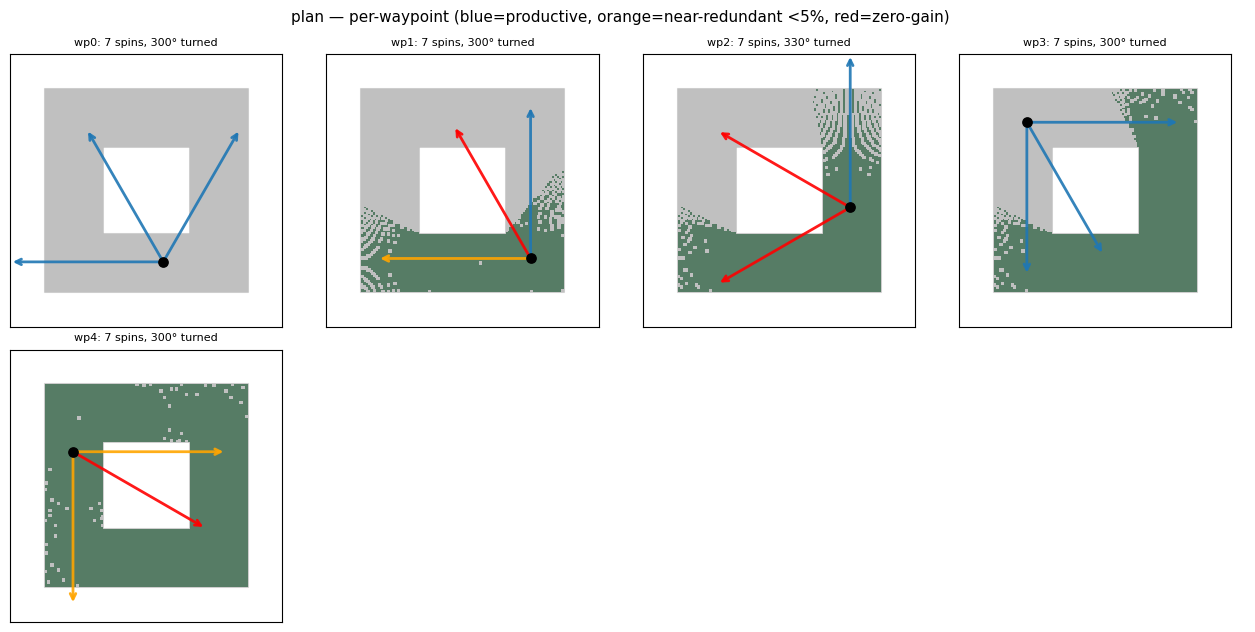

  arrival  ANG_TRAVEL=  1170°  spins= 22  cov/deg= 10.2  near-redundant(<5%)= 7  (zero-gain=0)


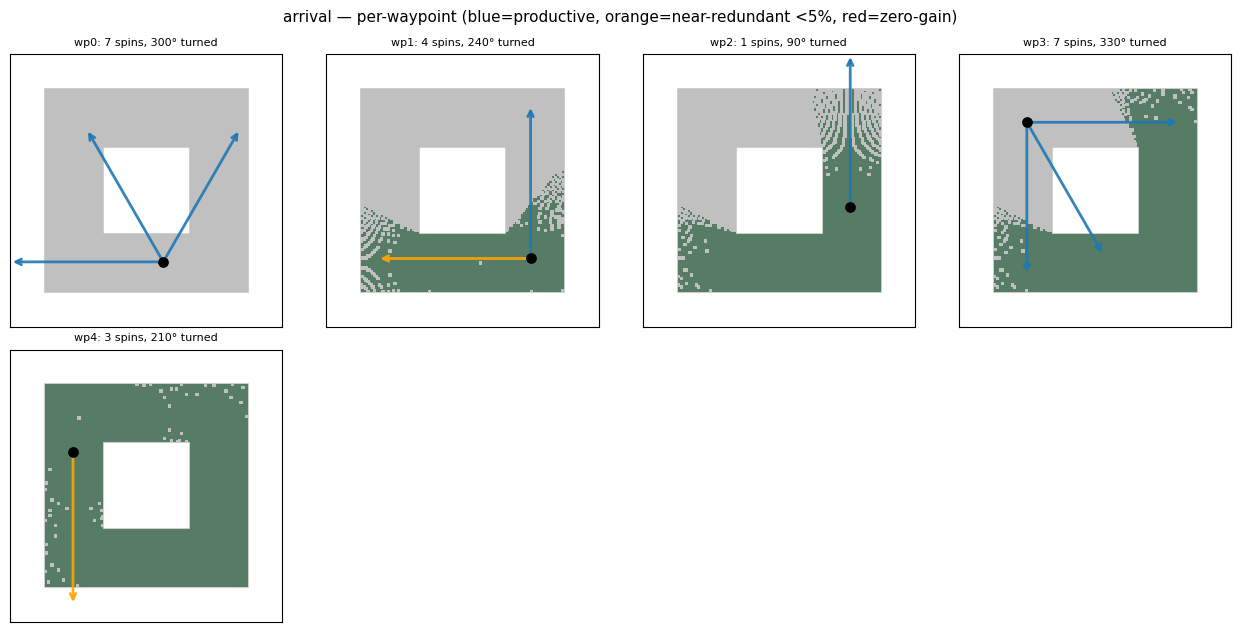

In [5]:
import matplotlib.pyplot as plt
from exploration.explore_costmap_map import pixel_to_world

# A spin is "near-redundant" if it adds < NEAR_REDUNDANT_FRAC of the best single-spin gain in the
# run — it barely paid for the turn. Captures partial waste, not only exactly-zero-gain spins.
NEAR_REDUNDANT_FRAC = 0.05

def simulate_instrumented(md, cfg, mode, start_cx, start_cy, max_iters=200):
    """Drain-the-plan sim recording per-spin (wp_idx,col,row,heading,ang_step,new_cells) and the
    covered_mask snapshot BEFORE each waypoint's rotation. Same logic as simulate()."""
    md.covered_mask[:] = False
    H = md.pgm_array.shape[0]; res = md.resolution
    max_range_px = max(1, int(cfg["max_detection_range"]/res))
    inc = cfg["observation_rotation_increment"]; fov = cfg["fov_horizontal"]; nrays = cfg["num_rays"]
    session = ExplorationSession(md, cfg)
    rc, rr = session.nearest_start(start_cx, start_cy)
    rx, ry = pixel_to_world(rc, rr, res, md.origin_x, md.origin_y, H)
    heading = 0.0
    spins = []; wp_snapshots = []; wp_idx = 0
    for _ in range(max_iters):
        wps, ratio, nf, _ = session.plan_waypoints_raw(rx, ry)
        if (nf and ratio >= cfg["exploration_completion_threshold"]) or not wps:
            break
        for wp in wps:
            path = find_path(md.navigable_mask, (rc, rr), (wp.col, wp.row))
            if session.on_unreachable(wp, path):
                continue
            rc, rr = wp.col, wp.row; rx, ry = wp.x, wp.y
            wp_snapshots.append((wp_idx, wp.col, wp.row, md.covered_mask.copy()))
            rot_headings = (get_headings(wp, inc, heading) if mode == "plan"
                            else _arrival_headings(md, wp, cfg, max_range_px, heading))
            rot = RotationState(stop_after=3)
            for h in rot_headings:
                ang_step = abs((float(h) - heading + 180.0) % 360.0 - 180.0)
                heading = float(h)
                before = int(np.sum(md.covered_mask & md.free_mask))
                ratio = update_covered_mask(md, wp.col, wp.row, heading, fov, max_range_px, nrays)
                new_cells = int(np.sum(md.covered_mask & md.free_mask)) - before
                spins.append({"wp_idx": wp_idx, "col": wp.col, "row": wp.row,
                              "heading": heading, "ang_step": ang_step, "new_cells": new_cells})
                if not rot.update(ratio):
                    break
            session.on_arrive(wp); wp_idx += 1
    return spins, wp_snapshots, max_range_px, fov


def _near_redundant_ids(spins):
    """ids of spins adding < NEAR_REDUNDANT_FRAC of the peak single-spin gain (partial waste)."""
    if not spins:
        return set()
    peak = max(s["new_cells"] for s in spins) or 1
    return {id(s) for s in spins if s["new_cells"] < NEAR_REDUNDANT_FRAC * peak}


def summarise(mode, spins):
    """HEADLINE cost = total angular travel (proxy for time + drift), not spin count."""
    ang = sum(s["ang_step"] for s in spins)
    newc = sum(s["new_cells"] for s in spins)
    zero = sum(1 for s in spins if s["new_cells"] == 0)
    nr = len(_near_redundant_ids(spins))
    print(f"  {mode:<8} ANG_TRAVEL={ang:>6.0f}°  spins={len(spins):>3}  "
          f"cov/deg={newc/ang if ang else 0:>5.1f}  near-redundant(<5%)={nr:>2}  (zero-gain={zero})")


def plot_small_multiples(md, mode, spins, snapshots, max_range_px, fov, ncols=4):
    """One panel per waypoint: local crop, covered-before (green), heading arrows.
    Arrow colour: blue=productive, orange=near-redundant (<5% peak), red=zero-gain."""
    n = len(snapshots)
    if n == 0:
        return
    nr_ids = _near_redundant_ids(spins)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.2*nrows), squeeze=False)
    crop = int(max_range_px * 1.3); ray = max_range_px * 0.75
    for k, (wp_idx, col, row, cov_before) in enumerate(snapshots):
        ax = axes[k//ncols][k%ncols]
        r0, r1 = max(0, row-crop), min(md.free_mask.shape[0], row+crop)
        c0, c1 = max(0, col-crop), min(md.free_mask.shape[1], col+crop)
        ax.imshow(md.free_mask[r0:r1, c0:c1], cmap="Greys", origin="upper", alpha=0.25, extent=[c0,c1,r1,r0])
        cov = np.ma.masked_where(~cov_before, cov_before)
        ax.imshow(cov[r0:r1, c0:c1], cmap="Greens", origin="upper", alpha=0.55, vmin=0, vmax=1, extent=[c0,c1,r1,r0])
        wp_spins = [s for s in spins if s["wp_idx"] == wp_idx]
        for s in wp_spins:
            th = np.radians(s["heading"]); dx, dy = ray*np.cos(th), -ray*np.sin(th)  # -sin: row down
            color = ("red" if s["new_cells"] == 0 else
                     "orange" if id(s) in nr_ids else "tab:blue")
            ax.annotate("", xy=(col+dx, row+dy), xytext=(col, row),
                        arrowprops=dict(arrowstyle="->", color=color, lw=2, alpha=0.9))
        ax.scatter([col], [row], s=45, c="k", marker="o", zorder=3)
        ax_ang = sum(s["ang_step"] for s in wp_spins)
        ax.set_title(f"wp{wp_idx}: {len(wp_spins)} spins, {ax_ang:.0f}° turned", fontsize=8)
        ax.set_xlim(c0, c1); ax.set_ylim(r1, r0); ax.set_xticks([]); ax.set_yticks([])
    for k in range(n, nrows*ncols):
        axes[k//ncols][k%ncols].axis("off")
    fig.suptitle(f"{mode} — per-waypoint (blue=productive, orange=near-redundant <5%, red=zero-gain)",
                 fontsize=11)
    plt.tight_layout(); plt.show()


cfg = base_cfg()
VIZ_MAP = "ring"   # change to any key in MAPS
md = MAPS[VIZ_MAP]; H, W = md.pgm_array.shape
print(f"[{VIZ_MAP}]  headline cost = total angular travel (proxy for time + drift):")
for mode in ("plan", "arrival"):
    spins, snaps, mrp, fov = simulate_instrumented(md, cfg, mode, W//2, H//2)
    summarise(mode, spins)
    plot_small_multiples(md, mode, spins, snaps, mrp, fov)

### C: animation — watch the robot rotate and fill blind spots

One frame per spin: robot at the current waypoint, the FOV wedge for the heading it just turned to,
and the covered area growing green. **Red wedge = that spin covered zero new cells** (redundant).
Watching plan vs arrival side by side shows the plan-time run repeatedly sweeping already-green
areas (red flashes) while arrival-time only ever adds new green. Saved as a GIF next to the notebook
and displayed inline."

saved: /home/idlab332/workspace/ros_ws/src/TRAVIS/ros2_ws/src/navigation/exploration/tests/algo_evaluation/heading_rotation.gif


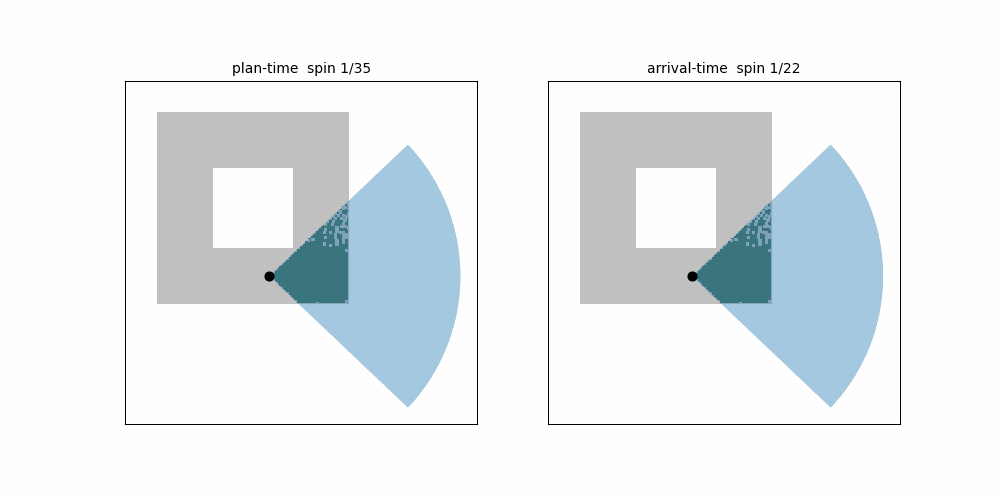

In [6]:
import matplotlib.animation as manim
from matplotlib.patches import Wedge
from IPython.display import Image as IPyImage

def capture_frames(md, cfg, mode, start_cx, start_cy, max_iters=200):
    """Like simulate_instrumented but snapshots (col,row,heading,new_cells, covered_after) AFTER
    each spin — one frame per spin for the animation."""
    md.covered_mask[:] = False
    H = md.pgm_array.shape[0]; res = md.resolution
    mrp = max(1, int(cfg["max_detection_range"]/res))
    inc = cfg["observation_rotation_increment"]; fov = cfg["fov_horizontal"]; nrays = cfg["num_rays"]
    session = ExplorationSession(md, cfg)
    rc, rr = session.nearest_start(start_cx, start_cy)
    rx, ry = pixel_to_world(rc, rr, res, md.origin_x, md.origin_y, H)
    heading = 0.0; frames = []
    for _ in range(max_iters):
        wps, ratio, nf, _ = session.plan_waypoints_raw(rx, ry)
        if (nf and ratio >= cfg["exploration_completion_threshold"]) or not wps:
            break
        for wp in wps:
            path = find_path(md.navigable_mask, (rc, rr), (wp.col, wp.row))
            if session.on_unreachable(wp, path):
                continue
            rc, rr = wp.col, wp.row; rx, ry = wp.x, wp.y
            rot_headings = (get_headings(wp, inc, heading) if mode == "plan"
                            else _arrival_headings(md, wp, cfg, mrp, heading))
            rot = RotationState(stop_after=3)
            for h in rot_headings:
                heading = float(h)
                before = int(np.sum(md.covered_mask & md.free_mask))
                ratio = update_covered_mask(md, wp.col, wp.row, heading, fov, mrp, nrays)
                new = int(np.sum(md.covered_mask & md.free_mask)) - before
                frames.append((wp.col, wp.row, heading, new, md.covered_mask.copy()))
                if not rot.update(ratio):
                    break
            session.on_arrive(wp)
    return frames, mrp, fov

cfg = base_cfg()
ANIM_MAP = "ring"
md = MAPS[ANIM_MAP]; H, W = md.pgm_array.shape
fr_plan, mrp, fov = capture_frames(md, cfg, "plan", W//2, H//2)
fr_arr, _, _      = capture_frames(md, cfg, "arrival", W//2, H//2)
nframes = max(len(fr_plan), len(fr_arr))

fig, (axp, axa) = plt.subplots(1, 2, figsize=(10, 5))
def draw(ax, frames, i, title):
    ax.clear(); ax.set_xticks([]); ax.set_yticks([])
    f = frames[min(i, len(frames)-1)]
    col, row, hd, new, cov = f
    ax.imshow(md.free_mask, cmap="Greys", origin="upper", alpha=0.25)
    ax.imshow(np.ma.masked_where(~cov, cov), cmap="Greens", origin="upper", alpha=0.6, vmin=0, vmax=1)
    if i < len(frames):  # draw current FOV wedge only while this run is still going
        color = "red" if new == 0 else "tab:blue"
        ax.add_patch(Wedge((col, row), mrp, -hd - fov/2, -hd + fov/2, alpha=0.4, facecolor=color))
        ax.scatter([col], [row], s=40, c="k", marker="o", zorder=3)
    done = min(i+1, len(frames))
    ax.set_title(f"{title}  spin {done}/{len(frames)}", fontsize=10)

def update(i):
    draw(axp, fr_plan, i, "plan-time")
    draw(axa, fr_arr, i, "arrival-time")
    return []

anim = manim.FuncAnimation(fig, update, frames=nframes, interval=500, blit=False)
gif_path = Path.cwd() / "heading_rotation.gif"
anim.save(str(gif_path), writer=manim.PillowWriter(fps=2))
plt.close(fig)
print("saved:", gif_path)
IPyImage(filename=str(gif_path))

## Outcome — arrival-time headings strictly better (once the sim matches the node)

**Correction:** the first version of this sim replanned after every waypoint, which structurally
erased the staleness and produced a false *tie*. The node actually **drains the whole plan**
(rotates at wp1..wpN, replans only when exhausted — `_finish_waypoint`), so wp2..wpN use plan-time
headings computed against a now-stale `covered_mask`. With the sim fixed to drain the plan:

| map | plan spins | arrival spins | Δspins | redundant (plan→arr) | coverage |
|-----|-----------:|--------------:|-------:|----------------------|---------:|
| lab_ghent | 40 | 25 | **−15** | 7→0 | same |
| lab_05 | 55 | 52 | −3 | 0→0 | same |
| ring | 35 | 22 | **−13** | 11→0 | same |
| L | 36 | 20 | **−16** | 11→0 | same |
| multi-region | 8 | 8 | 0 (1 wp) | 0→0 | same |
| open_room | 56 | 53 | −3 | 1→1 | same |

**Arrival-time headings strictly dominate:** fewer spins on 5/6 maps (tie on the single-waypoint
one), **identical coverage** everywhere. The `redundant` column is the mechanism — plan-time headings
waste up to 11 zero-gain spins per run aiming at cells already covered by earlier waypoints in the
same plan; arrival-time recompute (fresh `covered_mask`) drops those to 0.

**Interpretation:** this is optimisation, not a logic change — same `compute_headings_for_waypoint`,
fresher input. It's a real efficiency win (fewer physical rotations → faster exploration) with no
measured downside.

**Caveat / interaction:** this staleness only exists because the node drains a plan before
replanning (`docs/TODO_exploration_refactor.md` §11). Replanning per-waypoint would dissolve the
heading staleness *and* the SLAM-reactivity concern — so the arrival-time heading change is the
targeted fix, while §11 is the architectural one that would subsume it.